<a href="https://colab.research.google.com/github/Kushul08/DSA/blob/main/Deep_vision_crowd_monitor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!unzip /content/drive/MyDrive/ShanghaiTech.zip -d /content/


# ============================================================
#  CSRNet Preprocessing Script for ShanghaiTech Dataset
#  Compatible with Google Colab (stores processed data to Drive)
# ============================================================

# ---------- 1. Mount Google Drive ----------
from google.colab import drive
drive.mount('/content/drive')

import os, cv2, h5py, numpy as np, scipy.io as sio
from tqdm import tqdm
from scipy.ndimage import gaussian_filter

# ---------- 2. Configuration ----------
DATASET_PATH = "/content/ShanghaiTech"                    # Extracted dataset in Colab root
OUTPUT_PATH = "/content/drive/MyDrive/Processed_Shanghai"  # Processed dataset will be saved in Drive
TARGET_SIZE = (512, 512)                                  # Resize size (Width, Height)
GAUSSIAN_SIGMA = 15                                       # Smoothing factor
SHOW_VISUAL = False                                       # Debug display off (set True for preview)

os.makedirs(OUTPUT_PATH, exist_ok=True)

# ---------- 3. Helper Functions ----------
def preprocess_image(img, target_size):
    img = cv2.resize(img, target_size)
    img = img.astype(np.float32) / 255.0
    return img

def generate_density_map(image, points, sigma=GAUSSIAN_SIGMA):
    density = np.zeros(image.shape[:2], dtype=np.float32)
    for p in points:
        x = min(int(p[0]), image.shape[1] - 1)
        y = min(int(p[1]), image.shape[0] - 1)
        density[y, x] += 1
    density = gaussian_filter(density, sigma=sigma)
    return density

def generate_pointer_map(image, points, radius=3):
    pointer = np.zeros(image.shape[:2], dtype=np.uint8)
    for p in points:
        x = int(p[0])
        y = int(p[1])
        if 0 <= x < image.shape[1] and 0 <= y < image.shape[0]:
            cv2.circle(pointer, (x, y), radius, 255, -1)
    return pointer

def process_set(part, mode):
    img_dir = os.path.join(DATASET_PATH, f"part_{part}/{mode}_data/images")
# Note spelling for ground truth folder in your image: 'ground-truth'
    gt_dir  = os.path.join(DATASET_PATH, f"part_{part}/{mode}_data/ground-truth")

    out_dir = os.path.join(OUTPUT_PATH, f"part_{part}/{mode}")
    os.makedirs(out_dir, exist_ok=True)

    img_files = [f for f in os.listdir(img_dir) if f.endswith(".jpg")]

    for img_name in tqdm(img_files, desc=f"Processing part_{part} {mode}"):
        img_path = os.path.join(img_dir, img_name)
        mat_path = os.path.join(gt_dir, "GT_" + img_name.replace(".jpg", ".mat"))

        img = cv2.imread(img_path)
        if img is None:
            print(f"⚠️ Skipped unreadable image: {img_path}")
            continue

        mat = sio.loadmat(mat_path)
        points = mat["image_info"][0][0][0][0][0]  # (x,y) coordinates

        h, w = img.shape[:2]
        img_proc = preprocess_image(img, TARGET_SIZE)

        scale_x = TARGET_SIZE[0] / w
        scale_y = TARGET_SIZE[1] / h
        points_rescaled = np.zeros_like(points)
        points_rescaled[:, 0] = points[:, 0] * scale_x
        points_rescaled[:, 1] = points[:, 1] * scale_y

        pointer_map = generate_pointer_map(img_proc, points_rescaled, radius=2)
        density_map = generate_density_map(img_proc, points_rescaled, sigma=GAUSSIAN_SIGMA)

        save_path = os.path.join(out_dir, img_name.replace(".jpg", ".h5"))
        with h5py.File(save_path, "w") as hf:
            hf["image"] = img_proc
            hf["density"] = density_map
            hf["pointer"] = pointer_map
            hf["count"] = len(points)

# ---------- 4. Main Processing ----------
if __name__ == "__main__":
    for part in ["A", "B"]:
        for mode in ["train", "test"]:
            process_set(part, mode)

    print(f"\n✅ All done! Processed .h5 files saved to:\n{OUTPUT_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  /content/drive/MyDrive/ShanghaiTech.zip
   creating: /content/ShanghaiTech/
   creating: /content/ShanghaiTech/part_A/
   creating: /content/ShanghaiTech/part_A/test_data/
   creating: /content/ShanghaiTech/part_A/test_data/ground-truth/
 extracting: /content/ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_1.mat  
 extracting: /content/ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_10.mat  
 extracting: /content/ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_100.mat  
 extracting: /content/ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_101.mat  
 extracting: /content/ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_102.mat  
  inflating: /content/ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_103.mat  
 extracting: /content/ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_104.mat  
 extracting: /content/ShanghaiTech/part_A/test_data/

Processing part_B test: 100%|██████████| 316/316 [00:28<00:00, 11.22it/s]


✅ All done! Processed .h5 files saved to:
/content/drive/MyDrive/Processed_Shanghai


✅ Loaded: IMG_1.h5
👥 Ground Truth Count: 23
📏 Image Shape: (512, 512, 3)


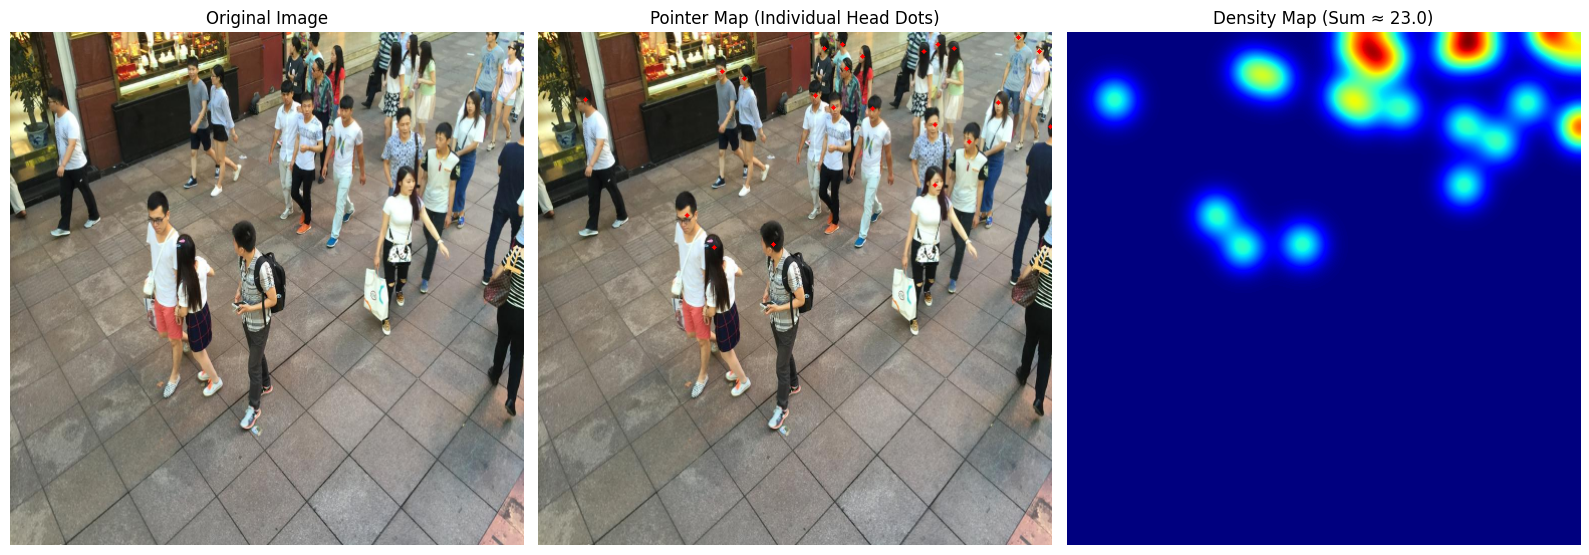

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# -----------------------------
# CONFIGURATION: point to file in Drive
# -----------------------------
H5_PATH = "/content/drive/MyDrive/Processed_Shanghai/part_B/test/IMG_1.h5"

# -----------------------------
# VISUALIZATION FUNCTION
# -----------------------------
def visualize_processed_sample(h5_path):
    if not os.path.exists(h5_path):
        print(f"❌ File not found: {h5_path}")
        return

    # ---- Load processed data ----
    with h5py.File(h5_path, "r") as f:
        image = f["image"][:]
        density = f["density"][:]
        pointer = f["pointer"][:]
        count = f["count"][()]

    print(f"✅ Loaded: {os.path.basename(h5_path)}")
    print(f"👥 Ground Truth Count: {int(count)}")
    print(f"📏 Image Shape: {image.shape}")

    # ---- Prepare overlays ----
    img_rgb = (image * 255).astype(np.uint8)
    pointer_overlay = img_rgb.copy()
    pointer_overlay[pointer > 0] = [0, 0, 255]  # Red dots for individuals

    # ---- Visualize ----
    plt.figure(figsize=(16, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(pointer_overlay, cv2.COLOR_BGR2RGB))
    plt.title("Pointer Map (Individual Head Dots)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(density, cmap='jet')
    plt.title(f"Density Map (Sum ≈ {density.sum():.1f})")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# -----------------------------
# MAIN EXECUTION
# -----------------------------
visualize_processed_sample(H5_PATH)

In [6]:
import json
import os

def update_json_list(json_path, processed_folder, suffix='.h5'):
    with open(json_path, 'r') as f:
        img_list = json.load(f)
    h5_list = [
        os.path.join(
            processed_folder,
            os.path.basename(path).replace(".jpg", suffix)
        )
        for path in img_list
    ]
    out_path = json_path.replace('.json', '_h5.json')
    with open(out_path, 'w') as f:
        json.dump(h5_list, f, indent=2)
    print(f'Updated JSON saved to: {out_path}')

# For Part A
update_json_list('/content/CSRNet-pytorch-master/part_A_train.json',
                 '/content/drive/MyDrive/Processed_Shanghai/part_A/train')
update_json_list('/content/CSRNet-pytorch-master/part_A_val.json',
                 '/content/drive/MyDrive/Processed_Shanghai/part_A/test') # or val if your split
update_json_list('/content/CSRNet-pytorch-master/part_A_test.json',
                 '/content/drive/MyDrive/Processed_Shanghai/part_A/test')
update_json_list('/content/CSRNet-pytorch-master/part_A_train_with_val.json',
                 '/content/drive/MyDrive/Processed_Shanghai/part_A/train')

# For Part B
update_json_list('/content/CSRNet-pytorch-master/part_B_train.json',
                 '/content/drive/MyDrive/Processed_Shanghai/part_B/train')
update_json_list('/content/CSRNet-pytorch-master/part_B_val.json',
                 '/content/drive/MyDrive/Processed_Shanghai/part_B/test') # or val if your split
update_json_list('/content/CSRNet-pytorch-master/part_B_test.json',
                 '/content/drive/MyDrive/Processed_Shanghai/part_B/test')
update_json_list('/content/CSRNet-pytorch-master/part_B_train_with_val.json',
                 '/content/drive/MyDrive/Processed_Shanghai/part_B/train')

Updated JSON saved to: /content/CSRNet-pytorch-master/part_A_train_h5.json
Updated JSON saved to: /content/CSRNet-pytorch-master/part_A_val_h5.json
Updated JSON saved to: /content/CSRNet-pytorch-master/part_A_test_h5.json
Updated JSON saved to: /content/CSRNet-pytorch-master/part_A_train_with_val_h5.json
Updated JSON saved to: /content/CSRNet-pytorch-master/part_B_train_h5.json
Updated JSON saved to: /content/CSRNet-pytorch-master/part_B_val_h5.json
Updated JSON saved to: /content/CSRNet-pytorch-master/part_B_test_h5.json
Updated JSON saved to: /content/CSRNet-pytorch-master/part_B_train_with_val_h5.json


In [5]:
!unzip /content/CSRNet-pytorch-master.zip -d /content/

Archive:  /content/CSRNet-pytorch-master.zip
ed29d895989c188cb913a9503721271c6cf1ab1f
   creating: /content/CSRNet-pytorch-master/
  inflating: /content/CSRNet-pytorch-master/README.md  
  inflating: /content/CSRNet-pytorch-master/dataset.py  
  inflating: /content/CSRNet-pytorch-master/image.py  
  inflating: /content/CSRNet-pytorch-master/make_dataset.ipynb  
  inflating: /content/CSRNet-pytorch-master/make_model.ipynb  
  inflating: /content/CSRNet-pytorch-master/model.py  
  inflating: /content/CSRNet-pytorch-master/part_A_test.json  
  inflating: /content/CSRNet-pytorch-master/part_A_train.json  
  inflating: /content/CSRNet-pytorch-master/part_A_train_with_val.json  
  inflating: /content/CSRNet-pytorch-master/part_A_val.json  
  inflating: /content/CSRNet-pytorch-master/part_B_test.json  
  inflating: /content/CSRNet-pytorch-master/part_B_train.json  
  inflating: /content/CSRNet-pytorch-master/part_B_train_with_val.json  
  inflating: /content/CSRNet-pytorch-master/part_B_val.j

In [7]:
import json

def merge_json_lists(json_files, output_json):
    combined_list = []
    for jf in json_files:
        with open(jf, 'r') as f:
            combined_list.extend(json.load(f))
    with open(output_json, 'w') as f:
        json.dump(combined_list, f, indent=2)
    print(f'Merged JSON saved to {output_json}')

# Merge training lists
merge_json_lists(
    ['/content/CSRNet-pytorch-master/part_A_train_h5.json', '/content/CSRNet-pytorch-master/part_B_train_h5.json'],
    '/content/CSRNet-pytorch-master/train_all_h5.json'
)

# Merge validation lists
merge_json_lists(
    ['/content/CSRNet-pytorch-master/part_A_val_h5.json', '/content/CSRNet-pytorch-master/part_B_val_h5.json'],
    '/content/CSRNet-pytorch-master/val_all_h5.json'
)

Merged JSON saved to /content/CSRNet-pytorch-master/train_all_h5.json
Merged JSON saved to /content/CSRNet-pytorch-master/val_all_h5.json


In [8]:
import json
import os

def report_missing(json_path):
    with open(json_path, 'r') as f:
        paths = json.load(f)
    missing = [p for p in paths if not os.path.exists(p)]
    print(f"Missing files in {json_path}:")
    for mf in missing:
        print(mf)
    return missing

missing_train = report_missing('/content/CSRNet-pytorch-master/train_all_h5.json')
missing_val = report_missing('/content/CSRNet-pytorch-master/val_all_h5.json')


Missing files in /content/CSRNet-pytorch-master/train_all_h5.json:
Missing files in /content/CSRNet-pytorch-master/val_all_h5.json:
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_289.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_221.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_233.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_188.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_187.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_246.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_259.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_245.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_203.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_183.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_273.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_299.h5
/content/drive/MyDrive/Processed_Shanghai/part_A/test/IMG_276.h5
/content/drive/MyDrive/

In [9]:
def clean_json(json_path):
    with open(json_path, 'r') as f:
        paths = json.load(f)
    valid_paths = [p for p in paths if os.path.exists(p)]
    with open(json_path, 'w') as f:
        json.dump(valid_paths, f, indent=2)
    print(f"Cleaned JSON saved to: {json_path}")

clean_json('/content/CSRNet-pytorch-master/train_all_h5.json')
clean_json('/content/CSRNet-pytorch-master/val_all_h5.json')


Cleaned JSON saved to: /content/CSRNet-pytorch-master/train_all_h5.json
Cleaned JSON saved to: /content/CSRNet-pytorch-master/val_all_h5.json


In [13]:
!python /content/CSRNet-pytorch-master/train.py \
  /content/CSRNet-pytorch-master/train_all_h5.json \
  /content/CSRNet-pytorch-master/val_all_h5.json \
  --pre '' 0 task_all


epoch 0, processed 0 samples, lr 0.0000001000
Epoch: [0][0/2800]	Time 0.655 (0.655)	Data 0.018 (0.018)	Loss 163.5907 (163.5907)	
Epoch: [0][30/2800]	Time 0.139 (0.163)	Data 0.014 (0.032)	Loss 126.9877 (159.9551)	
Epoch: [0][60/2800]	Time 0.138 (0.150)	Data 0.014 (0.024)	Loss 16.5759 (127.3060)	
Epoch: [0][90/2800]	Time 0.141 (0.150)	Data 0.014 (0.025)	Loss 90.6337 (151.5605)	
Epoch: [0][120/2800]	Time 0.139 (0.150)	Data 0.015 (0.027)	Loss 120.8379 (149.2777)	
Epoch: [0][150/2800]	Time 0.138 (0.149)	Data 0.015 (0.026)	Loss 19.2431 (160.5757)	
Epoch: [0][180/2800]	Time 0.141 (0.150)	Data 0.018 (0.027)	Loss 58.7699 (179.9334)	
Epoch: [0][210/2800]	Time 0.159 (0.150)	Data 0.014 (0.027)	Loss 88.6436 (167.8581)	
Epoch: [0][240/2800]	Time 0.143 (0.150)	Data 0.014 (0.028)	Loss 21.1402 (181.0226)	
Epoch: [0][270/2800]	Time 0.142 (0.150)	Data 0.017 (0.028)	Loss 24.5298 (195.5892)	
Epoch: [0][300/2800]	Time 0.142 (0.151)	Data 0.015 (0.029)	Loss 12.1836 (190.4538)	
Epoch: [0][330/2800]	Time 0.140 

In [14]:
!ls /content/drive/MyDrive/Processed_Shanghai/part_A/train/IMG_266.h5


ls: cannot access '/content/drive/MyDrive/Processed_Shanghai/part_A/train/IMG_266.h5': No such file or directory
